In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from scipy.optimize import curve_fit


import tifffile as tiff

film E1 median pixel value: 43253.0


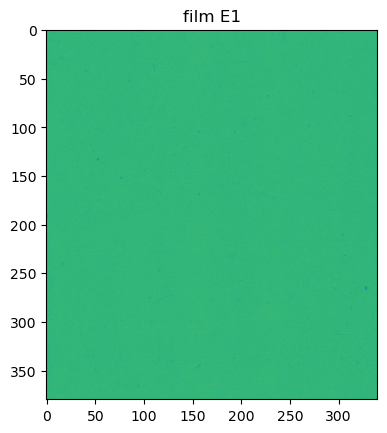

film E2 median pixel value: 43147.0


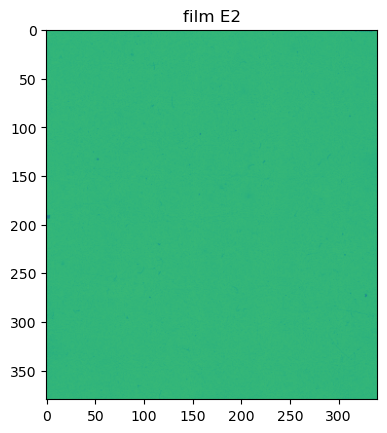

film E3 median pixel value: 40869.0


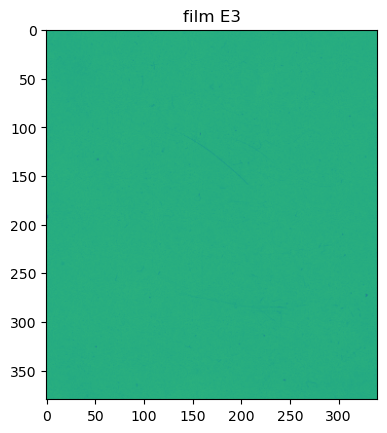

film E4 median pixel value: 40834.0


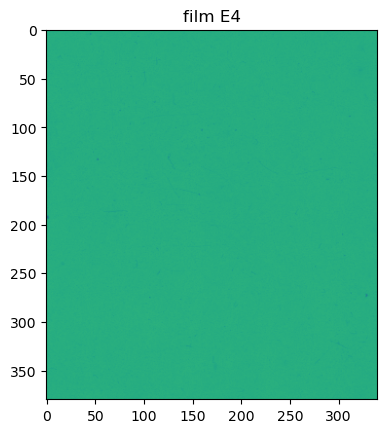

film E5 median pixel value: 37576.0


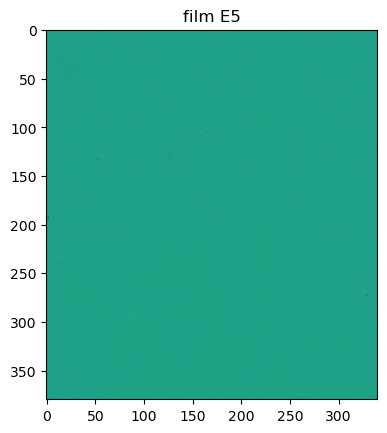

film E6 median pixel value: 37621.0


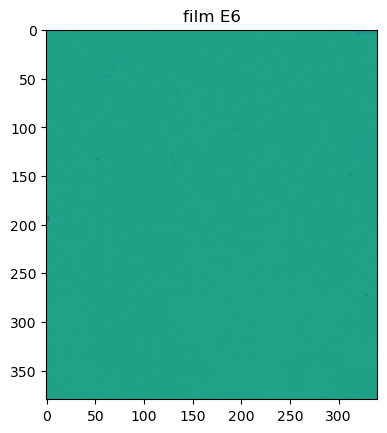

film E7 median pixel value: 33039.0


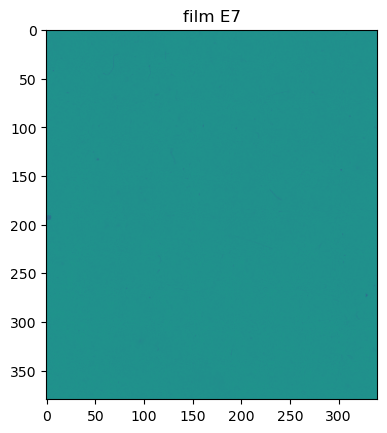

film E8 median pixel value: 33329.0


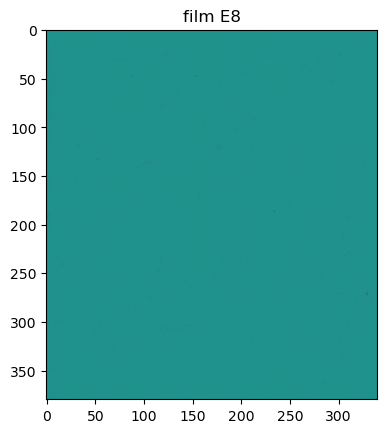

film E9 median pixel value: 27415.0


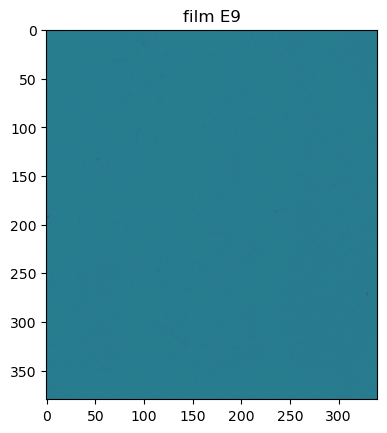

film E10 median pixel value: 27329.0


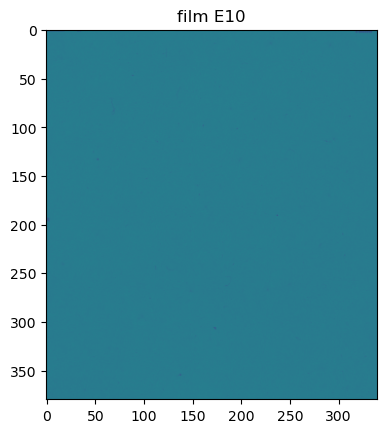

film E11 median pixel value: 23668.0


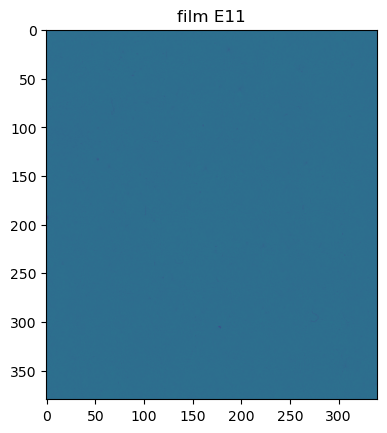

film E12 median pixel value: 23720.0


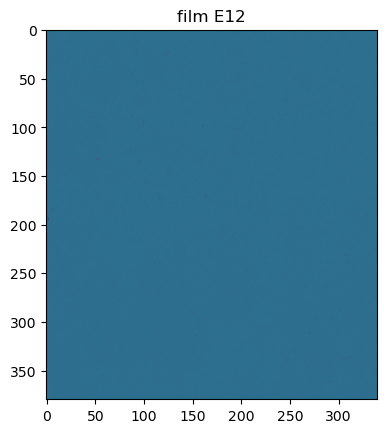

film E13 median pixel value: 21318.0


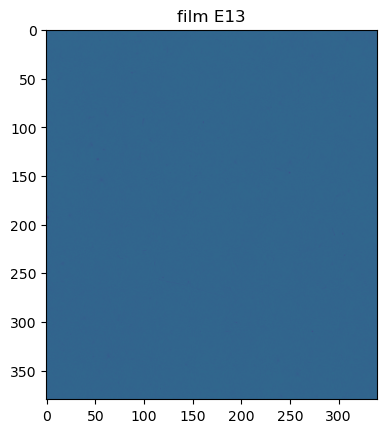

film E14 median pixel value: 21147.0


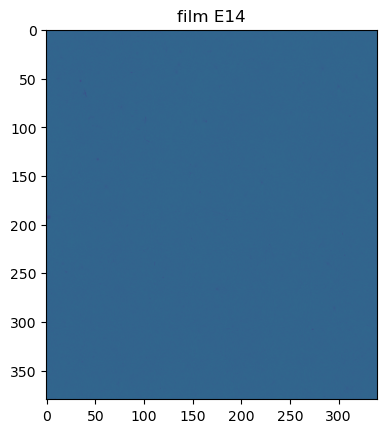

film E15 median pixel value: 19407.0


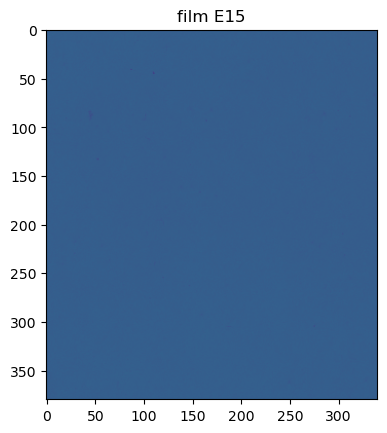

film E16 median pixel value: 19342.0


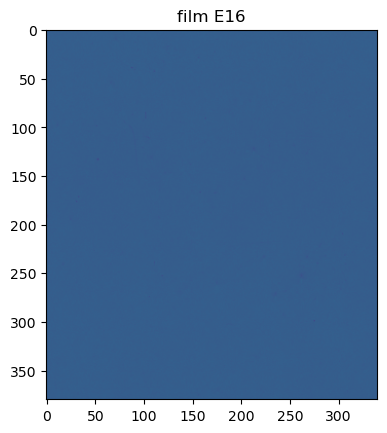

film E17 median pixel value: 17859.0


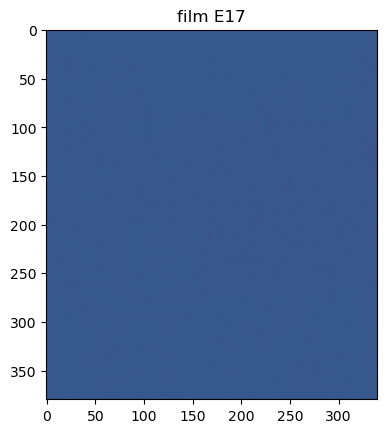

film E18 median pixel value: 17865.0


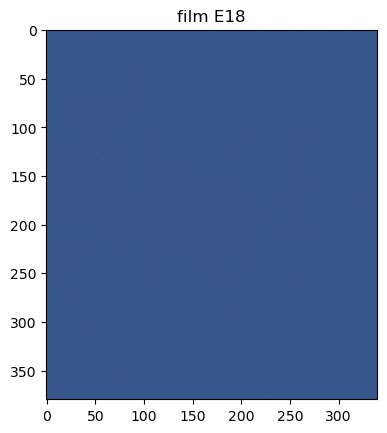

film E19 median pixel value: 16283.0


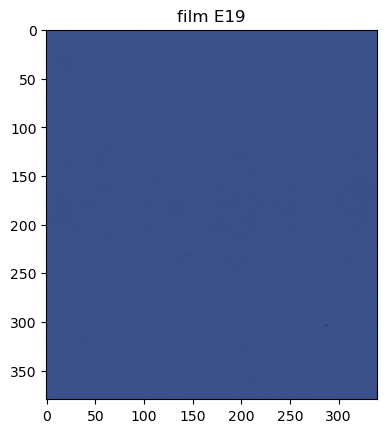

film E20 median pixel value: 16233.0


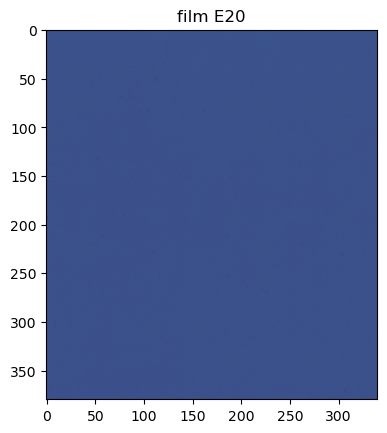

film E21 median pixel value: 14264.0


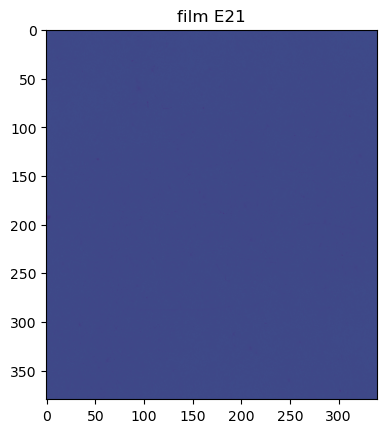

film E22 median pixel value: 14533.0


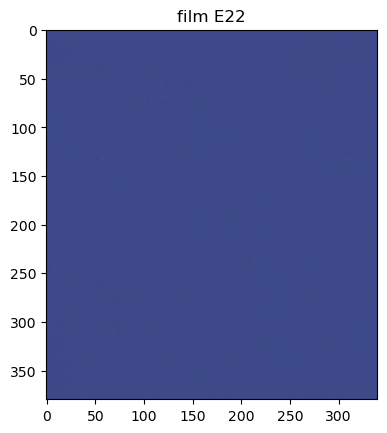

film E23 median pixel value: 13152.0


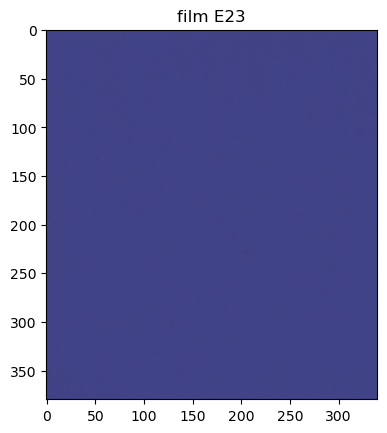

film E24 median pixel value: 13083.0


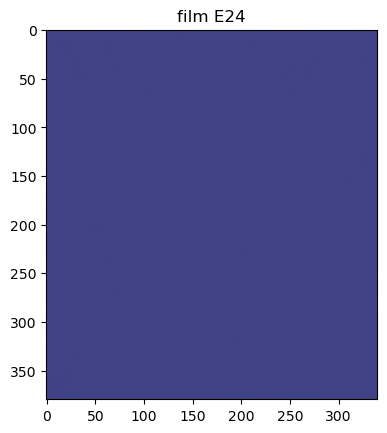

In [3]:
film_path = "CLEAR_dosimetry/FilmDosimetryGUI_macOS/Calibration-EBT4-03032503/24hpi/"
for i in range(1, 25):
    if i < 10:
        img = tiff.imread(f"{film_path}E_00{i}.tif")[50:430,30:370,:]
    else:
        img = tiff.imread(f"{film_path}E_0{i}.tif")[50:430,30:370,:] 

    
    channel = 0
    plt.imshow(img[:,:,channel],vmin=0,vmax=65535)
    print(f"film E{i} median pixel value: {np.median(img[:,:,channel])}")
    plt.title(f"film E{i}")
    plt.show()


In [10]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import tifffile as tiff

# Folder containing A_001.tif ... A_016.tif


# Map film label to delivered dose (Gy)
# Fill in any missing labels if needed.
import numpy as np
import tifffile as tiff
import pandas as pd

# dose_by_film = { #03032503 2026 jan 
#     "A01": 0.10009, "A02": 0.10009,
#     "A03": 0.99988, "A04": 0.99988,
#     "A05": 6.00025, "A06": 6.00025,
#     "A07": 8.99989, "A08": 8.99989,
#     "A09": 11.9995, "A10": 11.9995,
#     "A11": 19.9995, "A12": 19.9995,
#     "A13": 2.99964, "A14": 2.99964,
#     "A15": 0, "A16": 0
# }

# dose_by_film = {   #XD 10172501 2026 summer
#     "E01": 0.1997788, "E02": 0.1997788,
#     "E03": 0.9998638, "E04": 0.9998638,
#     "E05": 1.9997276, "E06": 1.9997276,
#     "E07": 4.000425, "E08": 4.000425,
#     "E09": 6.0001526, "E10": 6.0001526,
#     "E11": 7.9998802, "E12": 7.9998802,
#     "E13": 9.9996078, "E14": 9.9996078,
#     "E15": 14.9998966, "E16": 14.9998966,
#     "E17": 20.0001854, "E18": 20.0001854,
#     "E19": 25.0004742, "E20": 25.0004742,
#     "E21": 29.9997932, "E22": 29.9997932,
#     "E29": 35.000082, "E30": 35.000082,
#     "E23": 40.0003708, "E24": 40.0003708,
#     "E31": 44.9996898, "E32": 44.9996898,
#     "E25": 49.9999786, "E26": 49.9999786,
#     "E27": 59.9995864, "E28": 59.9995864,
#     "E33": 64.9998752,
#     "E34": 0, "E35": 0
# }

dose_by_film = { # EBT4 03032503 2026 summer
    "E01": 0.1997788, "E02": 0.1997788,
    "E03": 0.5004168, "E04": 0.5004168,
    "E05": 0.9998638, "E06": 0.9998638,
    "E07": 1.9997276, "E08": 1.9997276,
    "E09": 4.000425, "E10": 4.000425,
    "E11": 6.0001526, "E12": 6.0001526,
    "E13": 7.9998802, "E14": 7.9998802,
    "E15": 9.9996078, "E16": 9.9996078,
    "E17": 12.0003052, "E18": 12.0003052,
    "E19": 14.9998966, "E20": 14.9998966,
    "E21": 20.0001854, "E22": 20.0001854,
    "E23": 25.0004742, "E24": 25.0004742,
    "E25": 0, "E26": 0
}
films_df = pd.DataFrame({
    "film": list(dose_by_film.keys()),
    "dose_Gy": list(dose_by_film.values())
})

# Lists to store results
pv_red = []
pv_green = []
pv_blue = []

# Read pixel values keyed off each film's own number (parsed from its label),
# NOT off a fixed range(1,36) — dose_by_film's insertion order is not strictly
# numeric (e.g. E29/E30 come before E23/E24), so a positional range() readout
# desyncs the film label from its pixel data starting after E22.
for film in films_df["film"]:
    i = int(re.search(r"\d+", film).group())
    if i < 10:
        path = f"{film_path}E_00{i}.tif"
    else:
        path = f"{film_path}E_0{i}.tif"

    img = tiff.imread(path)[50:430, 30:370, :]

    # Compute mean per channel
    pv_red.append(np.median(img[:, :, 0]))
    pv_green.append(np.median(img[:, :, 1]))
    pv_blue.append(np.median(img[:, :, 2]))

# Add to dataframe
films_df["PV_red"] = pv_red
films_df["PV_green"] = pv_green
films_df["PV_blue"] = pv_blue

print(films_df)

   film    dose_Gy   PV_red  PV_green  PV_blue
0   E01   0.199779  43253.0   41070.0  30306.0
1   E02   0.199779  43147.0   40944.0  29950.0
2   E03   0.500417  40869.0   39397.0  29604.0
3   E04   0.500417  40834.0   39333.0  29507.0
4   E05   0.999864  37576.0   37042.0  28945.0
5   E06   0.999864  37621.0   36955.0  28666.0
6   E07   1.999728  33039.0   33302.0  27790.0
7   E08   1.999728  33329.0   33546.0  27957.0
8   E09   4.000425  27415.0   28030.0  26062.0
9   E10   4.000425  27329.0   27964.0  25991.0
10  E11   6.000153  23668.0   24098.0  24361.0
11  E12   6.000153  23720.0   24103.0  24415.0
12  E13   7.999880  21318.0   21319.0  23165.0
13  E14   7.999880  21147.0   21134.0  23081.0
14  E15   9.999608  19407.0   19171.0  22142.0
15  E16   9.999608  19342.0   19075.0  22020.0
16  E17  12.000305  17859.0   17209.0  20939.0
17  E18  12.000305  17865.0   17124.0  20895.0
18  E19  14.999897  16283.0   15030.0  19706.0
19  E20  14.999897  16233.0   14948.0  19583.0
20  E21  20.0

In [11]:
# --- Make sure these columns exist ---
for ch in ["red", "green", "blue"]:
    films_df[f"OD_{ch}"] = -np.log(films_df[f"PV_{ch}"] / 65535)

# Background = whichever films were delivered zero dose, rather than a
# hardcoded label list — the active dose_by_film dict (and hence which
# labels are the zero-dose films) changes between calibration batches.
background = films_df[films_df["dose_Gy"] == 0]

OD0 = {
    ch: background[f"OD_{ch}"].mean()
    for ch in ["red", "green", "blue"]
}

for ch in ["red", "green", "blue"]:
    films_df[f"nOD_{ch}"] = films_df[f"OD_{ch}"] - OD0[ch]

print(films_df.columns)  # optional check


Index(['film', 'dose_Gy', 'PV_red', 'PV_green', 'PV_blue', 'OD_red',
       'OD_green', 'OD_blue', 'nOD_red', 'nOD_green', 'nOD_blue'],
      dtype='str')


red: a=4.7904, b=0.1610, c=4.8297
   chi2 = 0.0009, reduced chi2 = 0.0000
green: a=7.7953, b=0.0283, c=7.7848
   chi2 = 0.0014, reduced chi2 = 0.0001
blue: a=19.3836, b=0.2079, c=19.1970
   chi2 = 0.0013, reduced chi2 = 0.0001


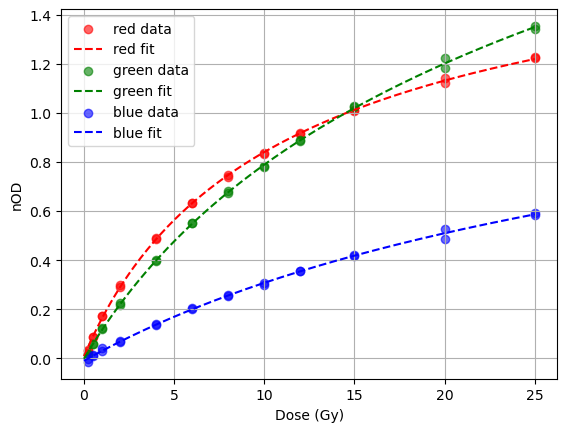

In [12]:
# --- Model ---
def nOD_model(D, a, b, c):
    return -np.log((a + b * D) / (c + D)) #natural logarithm

fit_params = {}
chi2_results = {}

D_plot = np.linspace(0, max(films_df["dose_Gy"]), 200)

plt.figure()

for ch, color in zip(["red", "green", "blue"], ["r", "g", "b"]):

    # Data (exclude zero dose)
    fit_df = films_df[films_df["dose_Gy"] > 0]
    D = fit_df["dose_Gy"].values
    y = fit_df[f"nOD_{ch}"].values

    # Fit
    p0 = [1, 0.1, 1]
    popt, pcov = curve_fit(nOD_model, D, y, p0=p0, maxfev=10000)

    fit_params[ch] = popt

    # --- Chi-squared ---
    y_fit = nOD_model(D, *popt)

    # If you don't have uncertainties, assume equal weights → σ = 1
    residuals = y - y_fit
    chi2 = np.sum((residuals)**2)

    # Reduced chi² (more useful)
    dof = len(y) - len(popt)
    chi2_red = chi2 / dof

    chi2_results[ch] = (chi2, chi2_red)

    print(f"{ch}: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}")
    print(f"   chi2 = {chi2:.4f}, reduced chi2 = {chi2_red:.4f}")

    # --- Plot ---
    plt.scatter(D, y, color=color, label=f"{ch} data",alpha=0.6)
    plt.plot(D_plot, nOD_model(D_plot, *popt), color=color, linestyle="--", label=f"{ch} fit")

plt.xlabel("Dose (Gy)")
plt.ylabel("nOD")
plt.legend()
plt.grid()
plt.show()


red (inverted fit): a=4.9960, b=0.1541, c=5.0891
   chi2 = 0.5790, reduced chi2 = 0.0276
green (inverted fit): a=7.8268, b=0.0271, c=7.8194
   chi2 = 1.0321, reduced chi2 = 0.0491
blue (inverted fit): a=20.2228, b=0.1910, c=20.0623
   chi2 = 3.3121, reduced chi2 = 0.1577


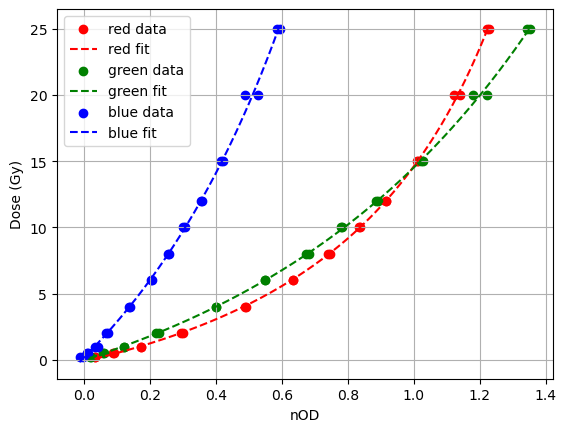

In [13]:

# --- Inverted model ---
def D_model(nOD, a, b, c):
    exp_term = np.exp(-nOD)
    return (a - c * exp_term) / (exp_term - b)

fit_params_inv = {}
chi2_results_inv = {}

plt.figure()

for ch, color in zip(["red", "green", "blue"], ["r", "g", "b"]):

    # Use only non-zero dose
    fit_df = films_df[films_df["dose_Gy"] > 0]

    x = fit_df[f"nOD_{ch}"].values   # nOD
    y = fit_df["dose_Gy"].values     # Dose

    # --- Initial guess (IMPORTANT here)
    p0 = [1, 0.01, 1]

    popt, pcov = curve_fit(D_model, x, y, p0=p0, maxfev=20000)

    fit_params_inv[ch] = popt

    # --- Chi-squared ---
    y_fit = D_model(x, *popt)
    residuals = y - y_fit

    chi2 = np.sum(residuals**2)
    dof = len(y) - len(popt)
    chi2_red = chi2 / dof

    chi2_results_inv[ch] = (chi2, chi2_red)

    print(f"{ch} (inverted fit): a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}")
    print(f"   chi2 = {chi2:.4f}, reduced chi2 = {chi2_red:.4f}")

    # --- Plot ---
    x_plot = np.linspace(min(x), max(x), 200)
    plt.scatter(x, y, color=color, label=f"{ch} data")
    plt.plot(x_plot, D_model(x_plot, *popt), color=color, linestyle="--", label=f"{ch} fit")

plt.xlabel("nOD")
plt.ylabel("Dose (Gy)")
plt.legend()
plt.grid()
plt.show()

red polynomial coefficients (p4 → p0):
[ 9.56465954e+00 -1.00096134e+01  1.01602326e+01  4.12083547e+00
  7.26233391e-03]
   chi2 = 0.096332, reduced chi2 = 0.010704
green polynomial coefficients (p4 → p0):
[ 1.46014808  0.98750624  4.57336183  8.33547864 -0.01277002]
   chi2 = 0.115504, reduced chi2 = 0.012834
blue polynomial coefficients (p4 → p0):
[129.62111299 -72.99599522  30.51809185  28.99559952   0.33870407]
   chi2 = 0.740384, reduced chi2 = 0.082265


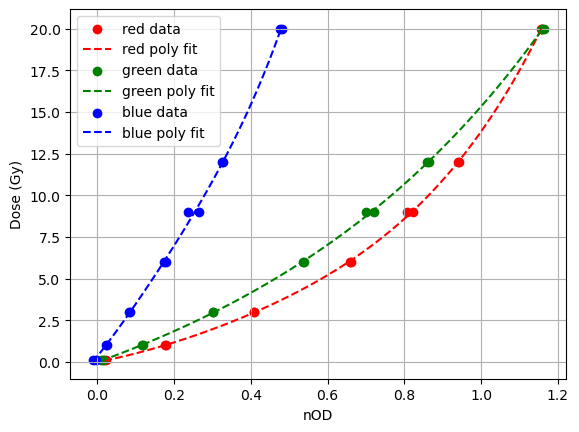

In [ ]:
#polynomial fit (degree 4) for comparison
poly_coeffs = {}
chi2_results_poly = {}

plt.figure()

for ch, color in zip(["red", "green", "blue"], ["r", "g", "b"]):

    # Use non-zero dose points
    fit_df = films_df[films_df["dose_Gy"] > 0]

    x = fit_df[f"nOD_{ch}"].values   # nOD
    y = fit_df["dose_Gy"].values     # Dose

    # --- Fit polynomial (degree 4) ---
    coeffs = np.polyfit(x, y, 4)  # returns [p4, p3, p2, p1, p0]
    poly = np.poly1d(coeffs)

    poly_coeffs[ch] = coeffs

    # --- Chi-squared ---
    y_fit = poly(x)
    residuals = y - y_fit

    chi2 = np.sum(residuals**2)
    dof = len(y) - 5  # 5 parameters
    chi2_red = chi2 / dof

    chi2_results_poly[ch] = (chi2, chi2_red)

    print(f"{ch} polynomial coefficients (p4 → p0):")
    print(coeffs)
    print(f"   chi2 = {chi2:.6f}, reduced chi2 = {chi2_red:.6f}")

    # --- Plot ---
    x_plot = np.linspace(x.min(), x.max(), 200)
    plt.scatter(x, y, color=color, label=f"{ch} data")
    plt.plot(x_plot, poly(x_plot), color=color, linestyle="--", label=f"{ch} poly fit")

plt.xlabel("nOD")
plt.ylabel("Dose (Gy)")
plt.legend()
plt.grid(True)
plt.show()